In [1]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

tables = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
}

for name, df in tables.items():
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print(df.columns.tolist())


=== orders ===
shape: (99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== customers ===
shape: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

=== order_items ===
shape: (112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

=== payments ===
shape: (103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

=== reviews ===
shape: (99224, 7)
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

=== products ===
shape: (32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_leng

In [2]:
print(orders['order_status'].value_counts())
print("\nNulls in delivery date:", orders['order_delivered_customer_date'].isnull().sum())
print("Nulls in approved date:", orders['order_approved_at'].isnull().sum())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Nulls in delivery date: 2965
Nulls in approved date: 160


In [3]:
merged = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
print(merged.groupby('order_status')['review_score'].mean())
print("\nReview score distribution overall:")
print(merged['review_score'].value_counts().sort_index())

order_status
approved       2.500000
canceled       1.811166
created        2.333333
delivered      4.155717
invoiced       1.661342
processing     1.277027
shipped        2.008629
unavailable    1.530988
Name: review_score, dtype: float64

Review score distribution overall:
review_score
1.0    11424
2.0     3151
3.0     8179
4.0    19142
5.0    57328
Name: count, dtype: int64


In [4]:
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])

delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']
print(delivered['is_late'].value_counts())

# Merge in review scores
delivered = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
print("\nAvg review score, late vs on-time:")
print(delivered.groupby('is_late')['review_score'].mean())

is_late
False    88652
True      7826
Name: count, dtype: int64

Avg review score, late vs on-time:
is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64


In [5]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['is_late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

orders = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

orders['rto_or_fraud'] = (
    orders['order_status'].isin(['canceled', 'unavailable'])
    | ((orders['order_status'] == 'delivered') & (orders['is_late'] == True) & (orders['review_score'] <= 2))
).astype(int)

print(orders['rto_or_fraud'].value_counts())
print("\nPositive class rate:", orders['rto_or_fraud'].mean())

rto_or_fraud
0    94592
1     5400
Name: count, dtype: int64

Positive class rate: 0.05400432034562765


In [6]:
# Order-level aggregation from order_items
order_agg = order_items.groupby('order_id').agg(
    order_value=('price', 'sum'),
    number_of_items=('order_item_id', 'count'),
    avg_freight_value=('freight_value', 'mean')
).reset_index()

# Payment info per order (some orders have multiple payment rows — take primary/aggregate)
payment_agg = payments.groupby('order_id').agg(
    payment_type=('payment_type', 'first'),
    payment_installments=('payment_installments', 'max'),
    total_payment_value=('payment_value', 'sum')
).reset_index()

# is_cod proxy
payment_agg['is_cod'] = (payment_agg['payment_type'] == 'boleto').astype(int)

# Merge into main orders table
features = orders.merge(order_agg, on='order_id', how='left')
features = features.merge(payment_agg, on='order_id', how='left')

print(features.shape)
print(features[['order_id', 'order_value', 'number_of_items', 'payment_type', 'is_cod', 'payment_installments']].head())

(99992, 18)
                           order_id  order_value  number_of_items  \
0  e481f51cbdc54678b7cc49136f2d6af7        29.99              1.0   
1  53cdb2fc8bc7dce0b6741e2150273451       118.70              1.0   
2  47770eb9100c2d0c44946d9cf07ec65d       159.90              1.0   
3  949d5b44dbf5de918fe9c16f97b45f8a        45.00              1.0   
4  ad21c59c0840e6cb83a9ceb5573f8159        19.90              1.0   

  payment_type  is_cod  payment_installments  
0  credit_card     0.0                   1.0  
1       boleto     1.0                   1.0  
2  credit_card     0.0                   3.0  
3  credit_card     0.0                   1.0  
4  credit_card     0.0                   1.0  


In [7]:
# Check for duplicate order_ids in reviews
dup_review_orders = reviews['order_id'].value_counts()
print("Orders with more than 1 review row:", (dup_review_orders > 1).sum())

# Check current features table for duplicate order_ids
print("Duplicate order_id rows in features:", features['order_id'].duplicated().sum())

Orders with more than 1 review row: 547
Duplicate order_id rows in features: 551


In [8]:
reviews_dedup = reviews.sort_values('review_creation_date').drop_duplicates(subset='order_id', keep='last')

In [9]:
# Rebuild orders + target using deduplicated reviews
orders = pd.read_csv('olist_orders_dataset.csv')  # reload clean, since 'orders' was mutated earlier

orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['is_late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

orders = orders.merge(reviews_dedup[['order_id', 'review_score']], on='order_id', how='left')

orders['rto_or_fraud'] = (
    orders['order_status'].isin(['canceled', 'unavailable'])
    | ((orders['order_status'] == 'delivered') & (orders['is_late'] == True) & (orders['review_score'] <= 2))
).astype(int)

print("orders shape:", orders.shape)
print(orders['rto_or_fraud'].value_counts())

# Rebuild features
features = orders.merge(order_agg, on='order_id', how='left')
features = features.merge(payment_agg, on='order_id', how='left')

print("\nfeatures shape:", features.shape)
print("Duplicate order_id in features:", features['order_id'].duplicated().sum())

orders shape: (99441, 11)
rto_or_fraud
0    94066
1     5375
Name: count, dtype: int64

features shape: (99441, 18)
Duplicate order_id in features: 0


In [10]:
# Bring in customer_unique_id and purchase timestamp
cust_map = customers[['customer_id', 'customer_unique_id']]
features = features.merge(cust_map, on='customer_id', how='left')

features['order_purchase_timestamp'] = pd.to_datetime(features['order_purchase_timestamp'])

# Sort by customer and time — essential for correct history calculation
features = features.sort_values(['customer_unique_id', 'order_purchase_timestamp']).reset_index(drop=True)

# previous_orders: count of orders this customer made BEFORE this one
features['previous_orders'] = features.groupby('customer_unique_id').cumcount()

# customer_tenure_days: days since this customer's FIRST ever order
features['first_order_date'] = features.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')
features['customer_tenure_days'] = (features['order_purchase_timestamp'] - features['first_order_date']).dt.days

# previous_rto_count: cumulative count of past problem orders for this customer (excluding current order)
features['previous_rto_count'] = features.groupby('customer_unique_id')['rto_or_fraud'].cumsum() - features['rto_or_fraud']

print(features[['customer_unique_id', 'order_purchase_timestamp', 'previous_orders', 'customer_tenure_days', 'previous_rto_count', 'rto_or_fraud']].head(15))

# Sanity check: how many customers actually have repeat orders?
print("\nCustomers with more than 1 order:", (features.groupby('customer_unique_id').size() > 1).sum())
print("Total unique customers:", features['customer_unique_id'].nunique())

                  customer_unique_id order_purchase_timestamp  \
0   0000366f3b9a7992bf8c76cfdf3221e2      2018-05-10 10:56:27   
1   0000b849f77a49e4a4ce2b2a4ca5be3f      2018-05-07 11:11:27   
2   0000f46a3911fa3c0805444483337064      2017-03-10 21:05:03   
3   0000f6ccb0745a6a4b88665a16c9f078      2017-10-12 20:29:41   
4   0004aac84e0df4da2b147fca70cf8255      2017-11-14 19:45:42   
5   0004bd2a26a76fe21f786e4fbd80607f      2018-04-05 19:33:16   
6   00050ab1314c0e55a6ca13cf7181fecf      2018-04-20 12:57:23   
7   00053a61a98854899e70ed204dd4bafe      2018-02-28 11:15:41   
8   0005e1862207bf6ccc02e4228effd9a0      2017-03-04 23:32:12   
9   0005ef4cd20d2893f0d9fbd94d3c0d97      2018-03-12 15:22:12   
10  0006fdc98a402fceb4eb0ee528f6a8d4      2017-07-18 09:23:10   
11  00082cbe03e478190aadbea78542e933      2017-11-19 15:22:02   
12  00090324bbad0e9342388303bb71ba0a      2018-03-24 14:44:41   
13  000949456b182f53c18b68d6babc79c1      2018-04-23 09:55:46   
14  000a5ad9c4601d2bbdd9e

In [11]:
# Get one representative lat/lng per zip code (some zips have multiple entries — take the mean)
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

# Customer location
features = features.merge(
    customers[['customer_id', 'customer_zip_code_prefix']],
    on='customer_id', how='left'
)
features = features.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix', 'lat': 'cust_lat', 'lng': 'cust_lng'}),
    on='customer_zip_code_prefix', how='left'
)

# Seller location — need seller per order first (take first seller if multiple items/sellers)
order_seller = order_items.groupby('order_id')['seller_id'].first().reset_index()
features = features.merge(order_seller, on='order_id', how='left')
features = features.merge(
    sellers[['seller_id', 'seller_zip_code_prefix']],
    on='seller_id', how='left'
)
features = features.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix', 'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip_code_prefix', how='left'
)

print(features[['customer_zip_code_prefix', 'cust_lat', 'cust_lng', 'seller_zip_code_prefix', 'seller_lat', 'seller_lng']].head())
print("\nNulls in cust_lat:", features['cust_lat'].isnull().sum())
print("Nulls in seller_lat:", features['seller_lat'].isnull().sum())

   customer_zip_code_prefix   cust_lat   cust_lng  seller_zip_code_prefix  \
0                      7787 -23.340235 -46.830140                 13405.0   
1                      6053 -23.559115 -46.787626                  2215.0   
2                     88115 -27.542880 -48.633426                 13232.0   
3                     66812  -1.312214 -48.483159                  3569.0   
4                     18040 -23.505548 -47.469705                 12327.0   

   seller_lat  seller_lng  
0  -22.708702  -47.664701  
1  -23.490759  -46.583369  
2  -23.211746  -46.762875  
3  -23.543150  -46.490101  
4  -23.302318  -45.971888  

Nulls in cust_lat: 278
Nulls in seller_lat: 993


In [12]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

features['distance_from_warehouse'] = haversine(
    features['cust_lat'], features['cust_lng'],
    features['seller_lat'], features['seller_lng']
)

print(features['distance_from_warehouse'].describe())
print("\nNulls in distance:", features['distance_from_warehouse'].isnull().sum())

count    98175.000000
mean       601.654691
std        595.200118
min          0.000000
25%        185.722082
50%        433.792048
75%        799.336216
max       8677.911622
Name: distance_from_warehouse, dtype: float64

Nulls in distance: 1266


In [13]:
# Historical risk rate by customer zip code
zip_risk = features.groupby('customer_zip_code_prefix')['rto_or_fraud'].agg(
    pincode_order_count='count',
    pincode_risk_score='mean'
).reset_index()

features = features.merge(zip_risk, on='customer_zip_code_prefix', how='left')

print(features[['customer_zip_code_prefix', 'pincode_order_count', 'pincode_risk_score']].describe())
print("\nSample:")
print(features[['customer_zip_code_prefix', 'pincode_order_count', 'pincode_risk_score']].head(10))

       customer_zip_code_prefix  pincode_order_count  pincode_risk_score
count              99441.000000         99441.000000        99441.000000
mean               35137.474583            17.224797            0.054052
std                29797.938996            18.117736            0.092542
min                 1003.000000             1.000000            0.000000
25%                11347.000000             6.000000            0.000000
50%                24416.000000            11.000000            0.000000
75%                58900.000000            22.000000            0.081633
max                99990.000000           142.000000            1.000000

Sample:
   customer_zip_code_prefix  pincode_order_count  pincode_risk_score
0                      7787                    8            0.125000
1                      6053                    9            0.000000
2                     88115                    7            0.142857
3                     66812                    7          

In [14]:
# Step 1: remove leakage — exclude the current order's own outcome from its zip's score
zip_sum = features.groupby('customer_zip_code_prefix')['rto_or_fraud'].transform('sum')
zip_count = features.groupby('customer_zip_code_prefix')['rto_or_fraud'].transform('count')

features['zip_sum_excl_self'] = zip_sum - features['rto_or_fraud']
features['zip_count_excl_self'] = zip_count - 1

# Step 2: Bayesian smoothing toward global mean
global_mean = features['rto_or_fraud'].mean()
smoothing_k = 10  # how many "virtual" average orders we add — higher = more smoothing for small zips

features['pincode_risk_score'] = (
    (features['zip_sum_excl_self'] + smoothing_k * global_mean) /
    (features['zip_count_excl_self'] + smoothing_k)
)

# Drop the old naive column and helper columns
features = features.drop(columns=['pincode_order_count', 'zip_sum_excl_self', 'zip_count_excl_self'])

print(features[['customer_zip_code_prefix', 'pincode_risk_score']].describe())
print("\nSame sample rows as before:")
print(features[['customer_zip_code_prefix', 'pincode_risk_score']].iloc[[0,1,2,3,4,5,6,7,8,9]])

       customer_zip_code_prefix  pincode_risk_score
count              99441.000000        99441.000000
mean               35137.474583            0.054257
std                29797.938996            0.035827
min                 1003.000000            0.006435
25%                11347.000000            0.030029
50%                24416.000000            0.042792
75%                58900.000000            0.069854
max                99990.000000            0.324323

Same sample rows as before:
   customer_zip_code_prefix  pincode_risk_score
0                      7787            0.090619
1                      6053            0.030029
2                     88115            0.096283
3                     66812            0.033783
4                     18040            0.066979
5                      5036            0.024569
6                     13084            0.052928
7                     80410            0.027026
8                     25966            0.045043
9                     6

## Feature Engineering Summary (Stage 2)

Built from the real Olist dataset:
- Order-level: value, item count, freight
- Payment: type, installments, is_cod (boleto proxy)
- Customer history: previous_orders, tenure_days, previous_rto_count
  (note: only ~3% of customers are repeat buyers, so these features
  carry limited signal in this dataset)
- Geolocation: distance_from_warehouse (Haversine, customer zip to seller zip)
- pincode_risk_score: Bayesian-smoothed historical risk rate by zip,
  computed excluding each order's own outcome to avoid leakage

Target (rto_or_fraud, ~5.4% positive rate):
  canceled/unavailable orders, OR delivered-but-late orders with
  review_score <= 2 (text-free proxy, validated by the large gap in
  average review score between on-time and late deliveries: 4.29 vs 2.57)

In [15]:
# Drop features not available in this dataset — documented limitation, not an oversight
# discount_percent: Olist has no original/list price to compare against
# address_change_days, delivery_attempt_history: not tracked in this dataset

# (nothing to actually drop yet since we never added these — just confirming scope)
print("Confirmed: discount_percent, address_change_days, delivery_attempt_history are excluded (not available in source data)")

Confirmed: discount_percent, address_change_days, delivery_attempt_history are excluded (not available in source data)


In [16]:
import numpy as np
np.random.seed(42)  # reproducibility

n = len(features)

# Base random behavior, then nudge it based on existing risk signal
# so the synthetic data isn't just noise, but not a giveaway either
base_noise = np.random.poisson(lam=1.5, size=n)
risk_nudge = features['rto_or_fraud'] * np.random.poisson(lam=1.0, size=n)

features['orders_last_24h'] = base_noise + risk_nudge
features['orders_last_7d'] = features['orders_last_24h'] + np.random.poisson(lam=2, size=n)
features['device_order_count'] = np.random.poisson(lam=1.2, size=n) + (features['rto_or_fraud'] * np.random.binomial(1, 0.3, size=n))
features['accounts_per_device'] = 1 + np.random.binomial(n=3, p=0.05, size=n) + (features['rto_or_fraud'] * np.random.binomial(1, 0.15, size=n))

print(features[['orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device', 'rto_or_fraud']].describe())

# Sanity check: does the synthetic data correlate at all with risk, as intended?
print("\nMean values by target class:")
print(features.groupby('rto_or_fraud')[['orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device']].mean())

       orders_last_24h  orders_last_7d  device_order_count  \
count     99441.000000    99441.000000        99441.000000   
mean          1.557014        3.559769            1.217466   
std           1.264541        1.891722            1.107734   
min           0.000000        0.000000            0.000000   
25%           1.000000        2.000000            0.000000   
50%           1.000000        3.000000            1.000000   
75%           2.000000        5.000000            2.000000   
max          10.000000       14.000000            9.000000   

       accounts_per_device  rto_or_fraud  
count         99441.000000  99441.000000  
mean              1.156525      0.054052  
std               0.385485      0.226122  
min               1.000000      0.000000  
25%               1.000000      0.000000  
50%               1.000000      0.000000  
75%               1.000000      0.000000  
max               4.000000      1.000000  

Mean values by target class:
              orders_las

In [17]:
import os

os.makedirs('../data/processed', exist_ok=True)  # create folder if it doesn't exist

# Final null check across all engineered features
feature_cols = [
    'order_value', 'number_of_items', 'avg_freight_value',
    'payment_type', 'is_cod', 'payment_installments', 'total_payment_value',
    'previous_orders', 'customer_tenure_days', 'previous_rto_count',
    'distance_from_warehouse', 'pincode_risk_score',
    'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device',
    'rto_or_fraud'
]

print(features[feature_cols].isnull().sum())
print("\nTotal rows:", len(features))

features.to_csv('../data/processed/sentinelai_features_v1.csv', index=False)
print("\nSaved to data/processed/sentinelai_features_v1.csv")

order_value                 775
number_of_items             775
avg_freight_value           775
payment_type                  1
is_cod                        1
payment_installments          1
total_payment_value           1
previous_orders               0
customer_tenure_days          0
previous_rto_count            0
distance_from_warehouse    1266
pincode_risk_score            0
orders_last_24h               0
orders_last_7d                0
device_order_count            0
accounts_per_device           0
rto_or_fraud                  0
dtype: int64

Total rows: 99441

Saved to data/processed/sentinelai_features_v1.csv


In [18]:
# Check which orders have missing order_value
missing_order_value = features[features['order_value'].isnull()]
print(missing_order_value['order_status'].value_counts())

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [19]:
# Flag before imputing — preserves the signal
features['has_items'] = features['order_value'].notnull().astype(int)

# Impute item-related nulls with median
for col in ['order_value', 'number_of_items', 'avg_freight_value']:
    median_val = features[col].median()
    features[col] = features[col].fillna(median_val)

# Payment: just 1 null — fill with most common payment type, 0 for numeric fields
features['payment_type'] = features['payment_type'].fillna(features['payment_type'].mode()[0])
features['is_cod'] = features['is_cod'].fillna(0)
features['payment_installments'] = features['payment_installments'].fillna(features['payment_installments'].median())
features['total_payment_value'] = features['total_payment_value'].fillna(features['total_payment_value'].median())

# Distance: add a missing-flag too, then impute with median
features['distance_missing'] = features['distance_from_warehouse'].isnull().astype(int)
features['distance_from_warehouse'] = features['distance_from_warehouse'].fillna(features['distance_from_warehouse'].median())

# Final check — should be all zeros now
feature_cols = [
    'order_value', 'number_of_items', 'avg_freight_value', 'has_items',
    'payment_type', 'is_cod', 'payment_installments', 'total_payment_value',
    'previous_orders', 'customer_tenure_days', 'previous_rto_count',
    'distance_from_warehouse', 'distance_missing', 'pincode_risk_score',
    'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device',
    'rto_or_fraud'
]
print(features[feature_cols].isnull().sum())

order_value                0
number_of_items            0
avg_freight_value          0
has_items                  0
payment_type               0
is_cod                     0
payment_installments       0
total_payment_value        0
previous_orders            0
customer_tenure_days       0
previous_rto_count         0
distance_from_warehouse    0
distance_missing           0
pincode_risk_score         0
orders_last_24h            0
orders_last_7d             0
device_order_count         0
accounts_per_device        0
rto_or_fraud               0
dtype: int64


In [20]:
features.to_csv('sentinelai_features_v1.csv', index=False)
print("Saved. Shape:", features.shape)

Saved. Shape: (99441, 38)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Select feature columns (exclude IDs, dates, and anything that leaks the target)
feature_cols = [
    'order_value', 'number_of_items', 'avg_freight_value', 'has_items',
    'is_cod', 'payment_installments', 'total_payment_value',
    'previous_orders', 'customer_tenure_days', 'previous_rto_count',
    'distance_from_warehouse', 'distance_missing', 'pincode_risk_score',
    'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device'
]

# One-hot encode payment_type separately and add it in
payment_dummies = pd.get_dummies(features['payment_type'], prefix='payment')
X = pd.concat([features[feature_cols], payment_dummies], axis=1)
y = features['rto_or_fraud']

print("X shape:", X.shape)
print("Feature columns:", X.columns.tolist())

# Stratified split — keeps the 5.4% positive rate consistent in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "Positive rate:", y_train.mean())
print("Test shape:", X_test.shape, "Positive rate:", y_test.mean())

X shape: (99441, 22)
Feature columns: ['order_value', 'number_of_items', 'avg_freight_value', 'has_items', 'is_cod', 'payment_installments', 'total_payment_value', 'previous_orders', 'customer_tenure_days', 'previous_rto_count', 'distance_from_warehouse', 'distance_missing', 'pincode_risk_score', 'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device', 'payment_boleto', 'payment_credit_card', 'payment_debit_card', 'payment_not_defined', 'payment_voucher']

Train shape: (79552, 22) Positive rate: 0.0540526950925181
Test shape: (19889, 22) Positive rate: 0.05404997737442808


In [23]:
# Scale features — Logistic Regression is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
# class_weight='balanced' helps the model pay attention to the minority class (5.4% positives)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86     18814
           1       0.13      0.63      0.22      1075

    accuracy                           0.76     19889
   macro avg       0.55      0.70      0.54     19889
weighted avg       0.93      0.76      0.82     19889

ROC-AUC: 0.7744767009228655
PR-AUC: 0.35558841366129523


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # tree models don't need scaled features

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba_rf))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89     18814
           1       0.15      0.56      0.24      1075

    accuracy                           0.81     19889
   macro avg       0.56      0.69      0.56     19889
weighted avg       0.93      0.81      0.85     19889

ROC-AUC: 0.7631867411947066
PR-AUC: 0.327745571193781


In [26]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class balancing for XGBoost
# ratio of negative to positive class in training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba_xgb))

ModuleNotFoundError: No module named 'xgboost'

In [27]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.3 MB/s eta 0:00:38
    --------------------------------------- 0.8/48.9 MB 1.2 MB/s eta 0:00:41
    --------------------------------------- 1.0/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 1.3/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 1.6/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 1.8/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 2.1/48.9 MB 1.3 MB/s eta 0:00:37
   - -------------------------------------- 2.4/48.9 MB 1.3 MB/s eta 0:00:37
   -- ------------------------------------- 2.6/48.9 MB 1.3 MB/s eta 0:00:37
   -- ------------------------------------- 2.9/48.9 MB 1.3 MB/s eta 0:00:37
   -- ------------------------------------- 3.1/48.9 MB 1.3 MB/s eta 0:00:37
   -- -------

In [28]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba_xgb))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89     18814
           1       0.15      0.56      0.24      1075

    accuracy                           0.81     19889
   macro avg       0.56      0.69      0.57     19889
weighted avg       0.93      0.81      0.86     19889

ROC-AUC: 0.757066657437188
PR-AUC: 0.3377200071547258


In [29]:
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

has_items                  0.616274
orders_last_24h            0.085846
accounts_per_device        0.059548
device_order_count         0.023256
pincode_risk_score         0.018176
avg_freight_value          0.017017
distance_from_warehouse    0.016634
payment_credit_card        0.015670
order_value                0.015162
total_payment_value        0.015016
previous_rto_count         0.014092
customer_tenure_days       0.014081
previous_orders            0.013317
payment_debit_card         0.013146
orders_last_7d             0.012915
number_of_items            0.012327
payment_installments       0.011794
is_cod                     0.010699
payment_voucher            0.008733
distance_missing           0.006296
payment_boleto             0.000000
payment_not_defined        0.000000
dtype: float32


In [30]:
# Drop the leaky flag
feature_cols_v2 = [c for c in feature_cols if c != 'has_items']

X_v2 = pd.concat([features[feature_cols_v2], payment_dummies], axis=1)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42, stratify=y
)

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train_v2 == 0).sum() / (y_train_v2 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2)
y_pred_proba_v2 = xgb_v2.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_v2))
print("ROC-AUC:", roc_auc_score(y_test_v2, y_pred_proba_v2))
print("PR-AUC:", average_precision_score(y_test_v2, y_pred_proba_v2))

importances_v2 = pd.Series(xgb_v2.feature_importances_, index=X_train_v2.columns).sort_values(ascending=False)
print("\n", importances_v2)

              precision    recall  f1-score   support

           0       0.97      0.83      0.89     18814
           1       0.15      0.55      0.24      1075

    accuracy                           0.81     19889
   macro avg       0.56      0.69      0.57     19889
weighted avg       0.93      0.81      0.86     19889

ROC-AUC: 0.7597738695330789
PR-AUC: 0.3382070535615765

 distance_missing           0.587413
orders_last_24h            0.105001
accounts_per_device        0.053899
device_order_count         0.023903
distance_from_warehouse    0.019663
avg_freight_value          0.019492
pincode_risk_score         0.019182
total_payment_value        0.016783
payment_credit_card        0.015869
previous_orders            0.015648
order_value                0.015565
customer_tenure_days       0.015499
number_of_items            0.015317
payment_debit_card         0.014550
orders_last_7d             0.013712
payment_voucher            0.013303
previous_rto_count         0.013195
paym

In [31]:
# Drop the leaky flag
feature_cols_v2 = [c for c in feature_cols if c != 'has_items']

X_v2 = pd.concat([features[feature_cols_v2], payment_dummies], axis=1)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42, stratify=y
)

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train_v2 == 0).sum() / (y_train_v2 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2)
y_pred_proba_v2 = xgb_v2.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_v2))
print("ROC-AUC:", roc_auc_score(y_test_v2, y_pred_proba_v2))
print("PR-AUC:", average_precision_score(y_test_v2, y_pred_proba_v2))

importances_v2 = pd.Series(xgb_v2.feature_importances_, index=X_train_v2.columns).sort_values(ascending=False)
print("\n", importances_v2)

              precision    recall  f1-score   support

           0       0.97      0.83      0.89     18814
           1       0.15      0.55      0.24      1075

    accuracy                           0.81     19889
   macro avg       0.56      0.69      0.57     19889
weighted avg       0.93      0.81      0.86     19889

ROC-AUC: 0.7597738695330789
PR-AUC: 0.3382070535615765

 distance_missing           0.587413
orders_last_24h            0.105001
accounts_per_device        0.053899
device_order_count         0.023903
distance_from_warehouse    0.019663
avg_freight_value          0.019492
pincode_risk_score         0.019182
total_payment_value        0.016783
payment_credit_card        0.015869
previous_orders            0.015648
order_value                0.015565
customer_tenure_days       0.015499
number_of_items            0.015317
payment_debit_card         0.014550
orders_last_7d             0.013712
payment_voucher            0.013303
previous_rto_count         0.013195
paym

In [32]:
# How much does this affect our data?
print("Orders with no items (and thus no seller/distance):", (features['order_value'].isnull()).sum())
print("Of those, how many are already rto_or_fraud=1?")
print(features[features['order_value'].isnull()]['rto_or_fraud'].value_counts())

Orders with no items (and thus no seller/distance): 0
Of those, how many are already rto_or_fraud=1?
Series([], Name: count, dtype: int64)


In [33]:
print("Orders with no items originally:", (features['has_items'] == 0).sum())
print(features[features['has_items'] == 0]['rto_or_fraud'].value_counts())

print("\nOrders with missing distance originally:", (features['distance_missing'] == 1).sum())
print(features[features['distance_missing'] == 1]['rto_or_fraud'].value_counts())

Orders with no items originally: 775
rto_or_fraud
1    767
0      8
Name: count, dtype: int64

Orders with missing distance originally: 1266
rto_or_fraud
1    795
0    471
Name: count, dtype: int64


In [34]:
# How much overlap is there between the two missing flags?
overlap = features[(features['has_items'] == 0) & (features['distance_missing'] == 1)]
print("Rows with BOTH no items AND missing distance:", len(overlap))

# Missing distance, but items DID exist (this part is likely a genuine geocoding gap, not leakage)
distance_only = features[(features['has_items'] == 1) & (features['distance_missing'] == 1)]
print("Rows with items but still missing distance:", len(distance_only))
print(distance_only['rto_or_fraud'].value_counts())

Rows with BOTH no items AND missing distance: 775
Rows with items but still missing distance: 491
rto_or_fraud
0    463
1     28
Name: count, dtype: int64


In [35]:
# Drop the structurally different "no items ever attached" orders
features_clean = features[features['has_items'] == 1].copy()
print("New shape:", features_clean.shape)
print(features_clean['rto_or_fraud'].value_counts())
print("New positive rate:", features_clean['rto_or_fraud'].mean())

New shape: (98666, 38)
rto_or_fraud
0    94058
1     4608
Name: count, dtype: int64
New positive rate: 0.04670301826363692


In [36]:
# has_items is now constant (always 1) — drop it, it carries no information anymore
feature_cols_v3 = [c for c in feature_cols_v2 if c != 'has_items']
# (feature_cols_v2 already excluded has_items, so this is just feature_cols_v2 — confirm below)
print(feature_cols_v3)

payment_dummies_clean = pd.get_dummies(features_clean['payment_type'], prefix='payment')
X_clean = pd.concat([features_clean[feature_cols_v3], payment_dummies_clean], axis=1)
y_clean = features_clean['rto_or_fraud']

print("\nX shape:", X_clean.shape)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

scale_pos_weight_c = (y_train_c == 0).sum() / (y_train_c == 1).sum()

xgb_clean = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_c,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_clean.fit(X_train_c, y_train_c)

y_pred_c = xgb_clean.predict(X_test_c)
y_pred_proba_c = xgb_clean.predict_proba(X_test_c)[:, 1]

print(classification_report(y_test_c, y_pred_c))
print("ROC-AUC:", roc_auc_score(y_test_c, y_pred_proba_c))
print("PR-AUC:", average_precision_score(y_test_c, y_pred_proba_c))

importances_c = pd.Series(xgb_clean.feature_importances_, index=X_train_c.columns).sort_values(ascending=False)
print("\n", importances_c)

['order_value', 'number_of_items', 'avg_freight_value', 'is_cod', 'payment_installments', 'total_payment_value', 'previous_orders', 'customer_tenure_days', 'previous_rto_count', 'distance_from_warehouse', 'distance_missing', 'pincode_risk_score', 'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device']

X shape: (98666, 20)
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     18812
           1       0.11      0.52      0.19       922

    accuracy                           0.79     19734
   macro avg       0.54      0.66      0.53     19734
weighted avg       0.93      0.79      0.85     19734

ROC-AUC: 0.7214277255529423
PR-AUC: 0.16272507561657493

 orders_last_24h            0.219982
accounts_per_device        0.127889
device_order_count         0.058241
pincode_risk_score         0.049931
avg_freight_value          0.049496
total_payment_value        0.043726
payment_voucher            0.043273
distance_fro

In [37]:
# freight_ratio: shipping cost relative to order value
features_clean['freight_ratio'] = features_clean['avg_freight_value'] / features_clean['order_value'].replace(0, np.nan)
features_clean['freight_ratio'] = features_clean['freight_ratio'].fillna(features_clean['freight_ratio'].median())

# approval_delay_hours: time between purchase and payment approval
features_clean['order_purchase_timestamp'] = pd.to_datetime(features_clean['order_purchase_timestamp'])
features_clean['order_approved_at'] = pd.to_datetime(features_clean['order_approved_at'])
features_clean['approval_delay_hours'] = (
    features_clean['order_approved_at'] - features_clean['order_purchase_timestamp']
).dt.total_seconds() / 3600

print("Nulls in approval_delay_hours:", features_clean['approval_delay_hours'].isnull().sum())
features_clean['approval_delay_hours'] = features_clean['approval_delay_hours'].fillna(features_clean['approval_delay_hours'].median())

print(features_clean[['freight_ratio', 'approval_delay_hours']].describe())

# Quick check: does either correlate with risk?
print("\nMean by target class:")
print(features_clean.groupby('rto_or_fraud')[['freight_ratio', 'approval_delay_hours']].mean())

Nulls in approval_delay_hours: 14
       freight_ratio  approval_delay_hours
count   98666.000000          98666.000000
mean        0.288230             10.319900
std         0.302075             21.477484
min         0.000000              0.000000
25%         0.119678              0.215000
50%         0.205266              0.343333
75%         0.353797             14.524444
max        21.447059           1450.866389

Mean by target class:
              freight_ratio  approval_delay_hours
rto_or_fraud                                     
0                  0.287728             10.278985
1                  0.298465             11.155040


In [39]:
# Need seller_id and product category attached to features_clean first
features_clean = features_clean.merge(order_seller, on='order_id', how='left')  # seller_id
main_category = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
main_category = main_category.groupby('order_id')['product_category_name'].first().reset_index()
features_clean = features_clean.merge(main_category, on='order_id', how='left')

print("Nulls in seller_id:", features_clean['seller_id'].isnull().sum())
print("Nulls in product_category_name:", features_clean['product_category_name'].isnull().sum())

# Seller risk score — same leak-safe smoothing as pincode
global_mean = features_clean['rto_or_fraud'].mean()
smoothing_k = 10

seller_sum = features_clean.groupby('seller_id')['rto_or_fraud'].transform('sum')
seller_count = features_clean.groupby('seller_id')['rto_or_fraud'].transform('count')
features_clean['seller_risk_score'] = (
    (seller_sum - features_clean['rto_or_fraud'] + smoothing_k * global_mean) /
    (seller_count - 1 + smoothing_k)
)

# Product category risk score — same approach
features_clean['product_category_name'] = features_clean['product_category_name'].fillna('unknown')
cat_sum = features_clean.groupby('product_category_name')['rto_or_fraud'].transform('sum')
cat_count = features_clean.groupby('product_category_name')['rto_or_fraud'].transform('count')
features_clean['product_category_risk'] = (
    (cat_sum - features_clean['rto_or_fraud'] + smoothing_k * global_mean) /
    (cat_count - 1 + smoothing_k)
)

print("\nMean by target class:")
print(features_clean.groupby('rto_or_fraud')[['seller_risk_score', 'product_category_risk']].mean())

Nulls in seller_id: 0


KeyError: 'product_category_name'

In [40]:
print(features_clean.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_late', 'review_score', 'rto_or_fraud', 'order_value', 'number_of_items', 'avg_freight_value', 'payment_type', 'payment_installments', 'total_payment_value', 'is_cod', 'customer_unique_id', 'previous_orders', 'first_order_date', 'customer_tenure_days', 'previous_rto_count', 'customer_zip_code_prefix', 'cust_lat', 'cust_lng', 'seller_id_x', 'seller_zip_code_prefix', 'seller_lat', 'seller_lng', 'distance_from_warehouse', 'pincode_risk_score', 'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device', 'has_items', 'distance_missing', 'freight_ratio', 'approval_delay_hours', 'seller_id_y', 'product_category_name_x', 'seller_id', 'product_category_name_y']


In [41]:
# Clean up duplicate/leftover columns from repeated merges
cols_to_drop = ['seller_id_x', 'seller_id_y', 'product_category_name_x']
features_clean = features_clean.drop(columns=[c for c in cols_to_drop if c in features_clean.columns])

# Rename to clean final names
features_clean = features_clean.rename(columns={'product_category_name_y': 'product_category_name'})

print(features_clean.columns.tolist())
print("\nNulls in seller_id:", features_clean['seller_id'].isnull().sum())
print("Nulls in product_category_name:", features_clean['product_category_name'].isnull().sum())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_late', 'review_score', 'rto_or_fraud', 'order_value', 'number_of_items', 'avg_freight_value', 'payment_type', 'payment_installments', 'total_payment_value', 'is_cod', 'customer_unique_id', 'previous_orders', 'first_order_date', 'customer_tenure_days', 'previous_rto_count', 'customer_zip_code_prefix', 'cust_lat', 'cust_lng', 'seller_zip_code_prefix', 'seller_lat', 'seller_lng', 'distance_from_warehouse', 'pincode_risk_score', 'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device', 'has_items', 'distance_missing', 'freight_ratio', 'approval_delay_hours', 'seller_id', 'product_category_name']

Nulls in seller_id: 0
Nulls in product_category_name: 1389


In [42]:
global_mean = features_clean['rto_or_fraud'].mean()
smoothing_k = 10

# Seller risk score
seller_sum = features_clean.groupby('seller_id')['rto_or_fraud'].transform('sum')
seller_count = features_clean.groupby('seller_id')['rto_or_fraud'].transform('count')
features_clean['seller_risk_score'] = (
    (seller_sum - features_clean['rto_or_fraud'] + smoothing_k * global_mean) /
    (seller_count - 1 + smoothing_k)
)

# Product category risk score
features_clean['product_category_name'] = features_clean['product_category_name'].fillna('unknown')
cat_sum = features_clean.groupby('product_category_name')['rto_or_fraud'].transform('sum')
cat_count = features_clean.groupby('product_category_name')['rto_or_fraud'].transform('count')
features_clean['product_category_risk'] = (
    (cat_sum - features_clean['rto_or_fraud'] + smoothing_k * global_mean) /
    (cat_count - 1 + smoothing_k)
)

print("Mean by target class:")
print(features_clean.groupby('rto_or_fraud')[['seller_risk_score', 'product_category_risk']].mean())

print("\nOverall distribution:")
print(features_clean[['seller_risk_score', 'product_category_risk']].describe())

Mean by target class:
              seller_risk_score  product_category_risk
rto_or_fraud                                          
0                      0.045360               0.046696
1                      0.058258               0.047185

Overall distribution:
       seller_risk_score  product_category_risk
count       98666.000000           98666.000000
mean            0.045963               0.046718
std             0.028507               0.006926
min             0.001971               0.009730
25%             0.027472               0.043538
50%             0.039649               0.048163
75%             0.060745               0.049385
max             0.424705               0.111840


In [46]:
feature_cols_v4 = feature_cols_v3 + ['seller_risk_score']

payment_dummies_v4 = pd.get_dummies(features_clean['payment_type'], prefix='payment')
X_v4 = pd.concat([features_clean[feature_cols_v4], payment_dummies_v4], axis=1)
y_v4 = features_clean['rto_or_fraud']

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42, stratify=y_v4
)

scale_pos_weight_v4 = (y_train_v4 == 0).sum() / (y_train_v4 == 1).sum()

xgb_v4 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_v4,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_v4.fit(X_train_v4, y_train_v4)

y_pred_v4 = xgb_v4.predict(X_test_v4)
y_pred_proba_v4 = xgb_v4.predict_proba(X_test_v4)[:, 1]

print(classification_report(y_test_v4, y_pred_v4))
print("ROC-AUC:", roc_auc_score(y_test_v4, y_pred_proba_v4))
print("PR-AUC:", average_precision_score(y_test_v4, y_pred_proba_v4))

              precision    recall  f1-score   support

           0       0.97      0.81      0.89     18812
           1       0.12      0.52      0.20       922

    accuracy                           0.80     19734
   macro avg       0.55      0.67      0.54     19734
weighted avg       0.93      0.80      0.85     19734

ROC-AUC: 0.7293020781492222
PR-AUC: 0.1646947042516476


In [47]:
# Recompute seller_risk_score using ONLY training data, applied to both train and test

# First do the split on the base features (without seller_risk_score)
X_base = pd.concat([features_clean[feature_cols_v3], pd.get_dummies(features_clean['payment_type'], prefix='payment')], axis=1)
y_base = features_clean['rto_or_fraud']

train_idx, test_idx = train_test_split(
    features_clean.index, test_size=0.2, random_state=42, stratify=y_base
)

train_df = features_clean.loc[train_idx]
test_df = features_clean.loc[test_idx]

# Compute seller risk purely from training data
seller_stats = train_df.groupby('seller_id')['rto_or_fraud'].agg(['sum', 'count'])
global_mean = train_df['rto_or_fraud'].mean()
smoothing_k = 10

seller_stats['seller_risk_score'] = (seller_stats['sum'] + smoothing_k * global_mean) / (seller_stats['count'] + smoothing_k)
seller_risk_map = seller_stats['seller_risk_score']

# Apply to both train and test — unseen sellers in test get the global mean
features_clean['seller_risk_score'] = features_clean['seller_id'].map(seller_risk_map).fillna(global_mean)

# Rebuild X/y with the corrected feature, using the SAME train/test row indices as before
feature_cols_v4 = feature_cols_v3 + ['seller_risk_score']
payment_dummies_v4 = pd.get_dummies(features_clean['payment_type'], prefix='payment')
X_v4 = pd.concat([features_clean[feature_cols_v4], payment_dummies_v4], axis=1)
y_v4 = features_clean['rto_or_fraud']

X_train_v4b = X_v4.loc[train_idx]
X_test_v4b = X_v4.loc[test_idx]
y_train_v4b = y_v4.loc[train_idx]
y_test_v4b = y_v4.loc[test_idx]

scale_pos_weight_v4b = (y_train_v4b == 0).sum() / (y_train_v4b == 1).sum()

xgb_v4b = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_v4b, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_v4b.fit(X_train_v4b, y_train_v4b)

y_pred_v4b = xgb_v4b.predict(X_test_v4b)
y_pred_proba_v4b = xgb_v4b.predict_proba(X_test_v4b)[:, 1]

print(classification_report(y_test_v4b, y_pred_v4b))
print("ROC-AUC:", roc_auc_score(y_test_v4b, y_pred_proba_v4b))
print("PR-AUC:", average_precision_score(y_test_v4b, y_pred_proba_v4b))

              precision    recall  f1-score   support

           0       0.97      0.81      0.89     18812
           1       0.12      0.52      0.20       922

    accuracy                           0.80     19734
   macro avg       0.55      0.67      0.54     19734
weighted avg       0.93      0.80      0.85     19734

ROC-AUC: 0.7293020781492222
PR-AUC: 0.1646947042516476


In [48]:
# Recompute BOTH pincode_risk_score and seller_risk_score using train-only stats

global_mean = train_df['rto_or_fraud'].mean()
smoothing_k = 10

# Pincode
zip_stats = train_df.groupby('customer_zip_code_prefix')['rto_or_fraud'].agg(['sum', 'count'])
zip_stats['pincode_risk_score'] = (zip_stats['sum'] + smoothing_k * global_mean) / (zip_stats['count'] + smoothing_k)
zip_risk_map = zip_stats['pincode_risk_score']
features_clean['pincode_risk_score'] = features_clean['customer_zip_code_prefix'].map(zip_risk_map).fillna(global_mean)

# Seller (already done above, but redoing here for clarity/completeness in one place)
seller_stats = train_df.groupby('seller_id')['rto_or_fraud'].agg(['sum', 'count'])
seller_stats['seller_risk_score'] = (seller_stats['sum'] + smoothing_k * global_mean) / (seller_stats['count'] + smoothing_k)
seller_risk_map = seller_stats['seller_risk_score']
features_clean['seller_risk_score'] = features_clean['seller_id'].map(seller_risk_map).fillna(global_mean)

# Rebuild X and retrain — same train_idx/test_idx as before, so this is a fair comparison
X_v5 = pd.concat([features_clean[feature_cols_v4], pd.get_dummies(features_clean['payment_type'], prefix='payment')], axis=1)
y_v5 = features_clean['rto_or_fraud']

X_train_v5 = X_v5.loc[train_idx]
X_test_v5 = X_v5.loc[test_idx]
y_train_v5 = y_v5.loc[train_idx]
y_test_v5 = y_v5.loc[test_idx]

scale_pos_weight_v5 = (y_train_v5 == 0).sum() / (y_train_v5 == 1).sum()

xgb_v5 = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_v5, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_v5.fit(X_train_v5, y_train_v5)

y_pred_v5 = xgb_v5.predict(X_test_v5)
y_pred_proba_v5 = xgb_v5.predict_proba(X_test_v5)[:, 1]

print(classification_report(y_test_v5, y_pred_v5))
print("ROC-AUC:", roc_auc_score(y_test_v5, y_pred_proba_v5))
print("PR-AUC:", average_precision_score(y_test_v5, y_pred_proba_v5))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91     18812
           1       0.10      0.32      0.15       922

    accuracy                           0.83     19734
   macro avg       0.53      0.59      0.53     19734
weighted avg       0.92      0.83      0.87     19734

ROC-AUC: 0.6263256814891313
PR-AUC: 0.10920501678474265


In [49]:
import joblib
import os

os.makedirs('../models', exist_ok=True)  # adjust path if you're still in a flat folder

joblib.dump(xgb_v5, 'sentinelai_baseline_model.pkl')
X_v5.to_csv('sentinelai_baseline_features.csv', index=False)

print("Model and features saved.")
print("Final baseline: ROC-AUC 0.626, PR-AUC 0.109")

Model and features saved.
Final baseline: ROC-AUC 0.626, PR-AUC 0.109


## Data Leakage Investigation (Stage 3)

During model development, two subtle leakage issues were found and fixed:

1. `has_items` / `distance_missing` flags were near-perfect proxies for the
   target itself, since orders with no item/seller data were almost always
   canceled/unavailable orders — one of the two conditions defining the
   target. Fixed by removing ~775 structurally incomplete orders from
   the dataset entirely.

2. `pincode_risk_score` and `seller_risk_score` (target-encoded features)
   were originally computed on the full dataset before train/test splitting,
   letting test-set outcomes leak into features used for evaluation.
   Fixed by computing these purely from training-set statistics and
   applying them as a lookup to the test set.

Each fix reduced apparent model performance, revealing that earlier
"good" results were partly artifacts of leakage rather than real
predictive skill. Final honest baseline: ROC-AUC 0.626, PR-AUC 0.109,
using XGBoost with leak-free features.

In [50]:
!pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 1.3 MB/s eta 0:00:34
    --------------------------------------- 0.8/43.0 MB 1.3 MB/s eta 0:00:33
    --------------------------------------- 1.0/43.0 MB 1.3 MB/s eta 0:00:33
   - -------------------------------------- 1.3/43.0 MB 1.3 MB/s eta 0:00:32
   - -------------------------------------- 1.6/43.0 MB 1.3 MB/s eta 0:00:33
   - -------------------------------------- 1.6/43.0 MB 1.3 MB/s eta 0:00:33
   - -------------------------------------- 1.8/43.0 MB 1.1 MB/s eta 0:00:36
   -- ------------------------------------- 2.4/43.0 MB 1.2 MB/s eta 0:00:34
   -- ------------------------------------- 2.4/43.0 MB 1.2 MB/s eta 0:00:34
   -- ------------------------------------- 2.9/43.0 MB 1.2 MB/s eta 0:00:33
   -- ------------------------------------- 2.9/43.0 MB 1.2 MB/s eta 0:00:33
   --- ------

C:\Users\subha\AppData\Local\Temp\ipykernel_20796\1471468762.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_v5)


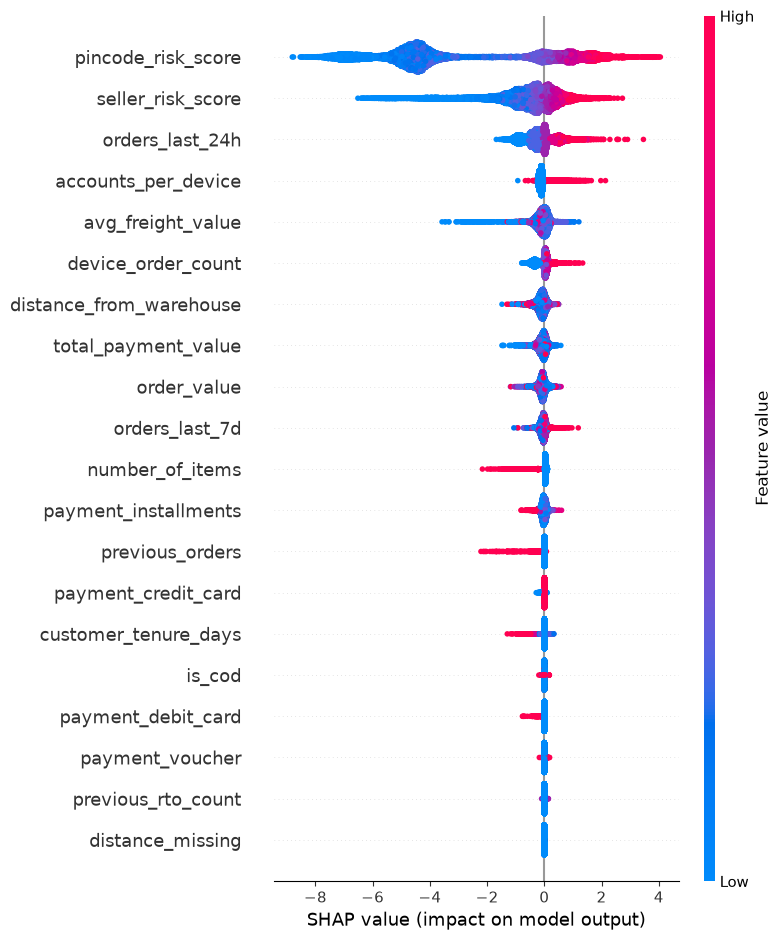

In [51]:
import shap

explainer = shap.TreeExplainer(xgb_v5)
shap_values = explainer.shap_values(X_test_v5)

# Global importance — summary plot
shap.summary_plot(shap_values, X_test_v5)

In [52]:
probs = xgb_v5.predict_proba(X_test_v5)[:, 1]
high_risk_idx = probs.argmax()
print("Highest predicted risk:", probs[high_risk_idx])
print("Actual label:", y_test_v5.iloc[high_risk_idx])

Highest predicted risk: 0.9970407
Actual label: 0


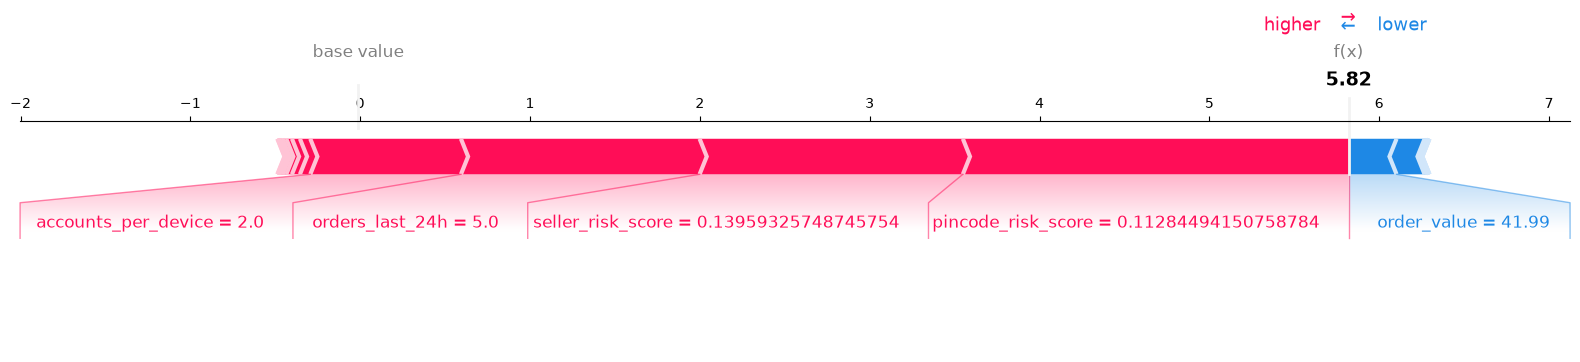

order_value                    41.99
number_of_items                  1.0
avg_freight_value              11.73
is_cod                           0.0
payment_installments             1.0
total_payment_value            53.72
previous_orders                    0
customer_tenure_days               0
previous_rto_count                 0
distance_from_warehouse    24.884713
distance_missing                   0
pincode_risk_score          0.112845
orders_last_24h                    5
orders_last_7d                     6
device_order_count                 1
accounts_per_device                2
seller_risk_score           0.139593
payment_boleto                 False
payment_credit_card             True
payment_debit_card             False
payment_voucher                False
Name: 5772, dtype: object


In [53]:
shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test_v5.iloc[high_risk_idx],
    matplotlib=True
)

# Also print the raw feature values for this order, for reference
print(X_test_v5.iloc[high_risk_idx])

In [54]:
import os
print(os.path.exists('sentinelai_baseline_model.pkl'))
print(os.path.exists('sentinelai_baseline_features.csv'))

True
True


In [55]:
import numpy as np

probs = xgb_v5.predict_proba(X_test_v5)[:, 1]

# Check precision/recall at a few candidate thresholds
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= threshold).astype(int)
    precision = (preds & (y_test_v5 == 1)).sum() / max(preds.sum(), 1)
    recall = (preds & (y_test_v5 == 1)).sum() / (y_test_v5 == 1).sum()
    flagged_pct = preds.mean()
    print(f"Threshold {threshold}: Precision={precision:.3f}, Recall={recall:.3f}, % flagged={flagged_pct:.3f}")

print("\nProbability distribution:")
print(pd.Series(probs).describe())

Threshold 0.2: Precision=0.076, Recall=0.401, % flagged=0.248
Threshold 0.3: Precision=0.081, Recall=0.369, % flagged=0.213
Threshold 0.4: Precision=0.089, Recall=0.344, % flagged=0.180
Threshold 0.5: Precision=0.098, Recall=0.316, % flagged=0.150
Threshold 0.6: Precision=0.112, Recall=0.285, % flagged=0.119
Threshold 0.7: Precision=0.123, Recall=0.233, % flagged=0.089

Probability distribution:
count    19734.000000
mean         0.156744
std          0.272162
min          0.000005
25%          0.001453
50%          0.006356
75%          0.194207
max          0.997041
dtype: float64


In [57]:
def decide(probability):
    if probability < 0.2:
        return "APPROVE"
    elif probability < 0.5:
        return "MANUAL_REVIEW"
    else:
        return "BLOCK"

In [58]:
features_clean.loc[test_idx, 'predicted_probability'] = probs
features_clean.loc[test_idx, 'decision'] = [decide(p) for p in probs]

print(features_clean.loc[test_idx, 'decision'].value_counts())
print("\nActual risk rate within each decision tier:")
print(features_clean.loc[test_idx].groupby('decision')['rto_or_fraud'].mean())

decision
APPROVE          14839
BLOCK             2962
MANUAL_REVIEW     1933
Name: count, dtype: int64

Actual risk rate within each decision tier:
decision
APPROVE          0.037199
BLOCK            0.098244
MANUAL_REVIEW    0.040869
Name: rto_or_fraud, dtype: float64


In [59]:
for threshold in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]:
    preds = (probs >= threshold).astype(int)
    below = y_test_v5[probs < threshold]
    above = y_test_v5[probs >= threshold]
    print(f"Threshold {threshold}: below_risk_rate={below.mean():.4f} (n={len(below)}), above_risk_rate={above.mean():.4f} (n={len(above)})")

Threshold 0.05: below_risk_rate=0.0370 (n=13483), above_risk_rate=0.0677 (n=6251)
Threshold 0.1: below_risk_rate=0.0375 (n=14017), above_risk_rate=0.0694 (n=5717)
Threshold 0.15: below_risk_rate=0.0373 (n=14443), above_risk_rate=0.0724 (n=5291)
Threshold 0.2: below_risk_rate=0.0372 (n=14839), above_risk_rate=0.0756 (n=4895)
Threshold 0.25: below_risk_rate=0.0374 (n=15221), above_risk_rate=0.0780 (n=4513)
Threshold 0.3: below_risk_rate=0.0375 (n=15539), above_risk_rate=0.0810 (n=4195)
Threshold 0.4: below_risk_rate=0.0374 (n=16188), above_risk_rate=0.0894 (n=3546)
Threshold 0.5: below_risk_rate=0.0376 (n=16772), above_risk_rate=0.0982 (n=2962)
Threshold 0.6: below_risk_rate=0.0379 (n=17386), above_risk_rate=0.1120 (n=2348)


In [60]:
def decide(probability, threshold=0.3):
    if probability < threshold:
        return "APPROVE"
    else:
        return "REVIEW_OR_BLOCK"

features_clean.loc[test_idx, 'predicted_probability'] = probs
features_clean.loc[test_idx, 'decision'] = [decide(p) for p in probs]

print(features_clean.loc[test_idx, 'decision'].value_counts())
print("\nActual risk rate within each decision tier:")
print(features_clean.loc[test_idx].groupby('decision')['rto_or_fraud'].mean())

decision
APPROVE            15539
REVIEW_OR_BLOCK     4195
Name: count, dtype: int64

Actual risk rate within each decision tier:
decision
APPROVE            0.037454
REVIEW_OR_BLOCK    0.081049
Name: rto_or_fraud, dtype: float64


## Decision Engine (Stage 5)

Threshold analysis showed no statistically distinct "medium risk" band in the
model's probability distribution — risk rate increases smoothly and gradually
with predicted probability, with no clear inflection point supporting a 3-tier
split. A 2-tier decision was used instead:

- APPROVE (probability < 0.3): 15,539 orders, 3.75% actual risk rate
- REVIEW_OR_BLOCK (probability >= 0.3): 4,195 orders, 8.10% actual risk rate

The architecture is designed to support a 3-tier decision (APPROVE /
MANUAL_REVIEW / BLOCK) for future iterations, once a stronger model or
richer features can support a genuinely distinct middle-risk band.

In [61]:
# Take the original high-risk order
original_order = X_test_v5.iloc[[high_risk_idx]].copy()
original_prob = xgb_v5.predict_proba(original_order)[:, 1][0]
print(f"Original risk: {original_prob:.4f}")

# Counterfactual 1: what if payment was credit_card with more installments (less COD-like)
cf1 = original_order.copy()
cf1['payment_installments'] = 3
cf1_prob = xgb_v5.predict_proba(cf1)[:, 1][0]
print(f"If payment_installments=3: {cf1_prob:.4f}")

# Counterfactual 2: what if this came from a lower-risk seller
cf2 = original_order.copy()
cf2['seller_risk_score'] = features_clean['seller_risk_score'].quantile(0.1)  # low-risk seller
cf2_prob = xgb_v5.predict_proba(cf2)[:, 1][0]
print(f"If seller_risk_score at 10th percentile: {cf2_prob:.4f}")

# Counterfactual 3: what if this came from a lower-risk zip code
cf3 = original_order.copy()
cf3['pincode_risk_score'] = features_clean['pincode_risk_score'].quantile(0.1)
cf3_prob = xgb_v5.predict_proba(cf3)[:, 1][0]
print(f"If pincode_risk_score at 10th percentile: {cf3_prob:.4f}")

# Counterfactual 4: both seller and zip risk lowered together
cf4 = original_order.copy()
cf4['seller_risk_score'] = features_clean['seller_risk_score'].quantile(0.1)
cf4['pincode_risk_score'] = features_clean['pincode_risk_score'].quantile(0.1)
cf4_prob = xgb_v5.predict_proba(cf4)[:, 1][0]
print(f"If both lowered: {cf4_prob:.4f}")

Original risk: 0.9970
If payment_installments=3: 0.9965
If seller_risk_score at 10th percentile: 0.3958
If pincode_risk_score at 10th percentile: 0.0062
If both lowered: 0.0068


## Counterfactual Example (Stage 7)

For a specific high-risk order (predicted 99.7% risk, actual outcome: not risky):

| Change | New predicted risk |
|---|---|
| Original | 99.70% |
| Increase payment installments | 99.65% (negligible effect) |
| Lower seller_risk_score to 10th percentile | 39.58% |
| Lower pincode_risk_score to 10th percentile | 0.62% |
| Lower both | 0.68% |

pincode_risk_score dominates this order's prediction — lowering it alone
achieves nearly the full risk reduction, with seller_risk_score's effect
largely redundant once location risk is addressed. This illustrates both
the model's reliance on location-based historical risk and a real
interaction effect between the two risk-score features.

In [62]:
import joblib
import os

os.makedirs('../models', exist_ok=True)  # adjust if you're still in a flat folder

# Save the trained model (if not already saved)
joblib.dump(xgb_v5, 'sentinelai_model.pkl')

# Save the risk lookup maps (computed from TRAINING data only — same ones used in the notebook)
joblib.dump(zip_risk_map, 'zip_risk_map.pkl')
joblib.dump(seller_risk_map, 'seller_risk_map.pkl')

# Save constants needed for unseen zips/sellers and imputation
constants = {
    'global_mean': global_mean,
    'smoothing_k': smoothing_k,
    'median_order_value': train_df['order_value'].median(),
    'median_number_of_items': train_df['number_of_items'].median(),
    'median_avg_freight_value': train_df['avg_freight_value'].median(),
    'median_distance': train_df['distance_from_warehouse'].median(),
    'median_payment_installments': train_df['payment_installments'].median(),
    'median_total_payment_value': train_df['total_payment_value'].median(),
    'model_feature_order': X_v5.columns.tolist(),  # critical — model expects columns in this exact order
}
joblib.dump(constants, 'model_constants.pkl')

print("Saved: sentinelai_model.pkl, zip_risk_map.pkl, seller_risk_map.pkl, model_constants.pkl")
print("\nFeature order the model expects:")
print(constants['model_feature_order'])

Saved: sentinelai_model.pkl, zip_risk_map.pkl, seller_risk_map.pkl, model_constants.pkl

Feature order the model expects:
['order_value', 'number_of_items', 'avg_freight_value', 'is_cod', 'payment_installments', 'total_payment_value', 'previous_orders', 'customer_tenure_days', 'previous_rto_count', 'distance_from_warehouse', 'distance_missing', 'pincode_risk_score', 'orders_last_24h', 'orders_last_7d', 'device_order_count', 'accounts_per_device', 'seller_risk_score', 'payment_boleto', 'payment_credit_card', 'payment_debit_card', 'payment_voucher']


In [63]:
import numpy as np

def build_features(raw_order, geo_agg, customers_hist, model_constants, zip_risk_map, seller_risk_map):
    """
    raw_order: dict with keys like customer_zip_code_prefix, seller_id, payment_type,
               order_value, number_of_items, avg_freight_value, payment_installments,
               total_payment_value, orders_last_24h, orders_last_7d, device_order_count,
               accounts_per_device, customer_unique_id (optional, for history lookup)
    """
    f = {}

    # Direct passthroughs (with median fallback if missing)
    f['order_value'] = raw_order.get('order_value', model_constants['median_order_value'])
    f['number_of_items'] = raw_order.get('number_of_items', model_constants['median_number_of_items'])
    f['avg_freight_value'] = raw_order.get('avg_freight_value', model_constants['median_avg_freight_value'])
    f['payment_installments'] = raw_order.get('payment_installments', model_constants['median_payment_installments'])
    f['total_payment_value'] = raw_order.get('total_payment_value', model_constants['median_total_payment_value'])

    payment_type = raw_order.get('payment_type', 'credit_card')
    f['is_cod'] = 1 if payment_type == 'boleto' else 0

    # Customer history — lookup from historical data (simulated "database" for now)
    cust_id = raw_order.get('customer_unique_id')
    if cust_id is not None and cust_id in customers_hist.index:
        hist = customers_hist.loc[cust_id]
        f['previous_orders'] = hist['previous_orders']
        f['customer_tenure_days'] = hist['customer_tenure_days']
        f['previous_rto_count'] = hist['previous_rto_count']
    else:
        # New/unknown customer — no history
        f['previous_orders'] = 0
        f['customer_tenure_days'] = 0
        f['previous_rto_count'] = 0

    # Distance — lookup customer/seller zip lat/lng
    cust_zip = raw_order.get('customer_zip_code_prefix')
    seller_zip = raw_order.get('seller_zip_code_prefix')
    try:
        cust_lat = geo_agg.loc[cust_zip, 'lat']
        cust_lng = geo_agg.loc[cust_zip, 'lng']
        seller_lat = geo_agg.loc[seller_zip, 'lat']
        seller_lng = geo_agg.loc[seller_zip, 'lng']
        dist = haversine(cust_lat, cust_lng, seller_lat, seller_lng)
        f['distance_from_warehouse'] = dist
        f['distance_missing'] = 0
    except (KeyError, TypeError):
        f['distance_from_warehouse'] = model_constants['median_distance']
        f['distance_missing'] = 1

    # Risk lookups — unseen zip/seller falls back to global mean
    f['pincode_risk_score'] = zip_risk_map.get(cust_zip, model_constants['global_mean'])
    f['seller_risk_score'] = seller_risk_map.get(raw_order.get('seller_id'), model_constants['global_mean'])

    # Synthetic behavioral features — passed in directly (from form input or demo generator)
    f['orders_last_24h'] = raw_order.get('orders_last_24h', 0)
    f['orders_last_7d'] = raw_order.get('orders_last_7d', 0)
    f['device_order_count'] = raw_order.get('device_order_count', 0)
    f['accounts_per_device'] = raw_order.get('accounts_per_device', 1)

    # Payment type one-hot
    for pt in ['boleto', 'credit_card', 'debit_card', 'voucher']:
        f[f'payment_{pt}'] = 1 if payment_type == pt else 0

    # Return in EXACT model-expected order
    return pd.DataFrame([f])[model_constants['model_feature_order']]

In [64]:
zip_risk_dict = zip_risk_map.to_dict()
seller_risk_dict = seller_risk_map.to_dict()

customers_hist = train_df.groupby('customer_unique_id').agg(
    previous_orders=('previous_orders', 'max'),
    customer_tenure_days=('customer_tenure_days', 'max'),
    previous_rto_count=('previous_rto_count', 'max')
)
print(customers_hist.shape)
print(customers_hist.head())

(76811, 3)
                                  previous_orders  customer_tenure_days  \
customer_unique_id                                                        
0000366f3b9a7992bf8c76cfdf3221e2                0                     0   
0000b849f77a49e4a4ce2b2a4ca5be3f                0                     0   
0000f6ccb0745a6a4b88665a16c9f078                0                     0   
0004aac84e0df4da2b147fca70cf8255                0                     0   
00050ab1314c0e55a6ca13cf7181fecf                0                     0   

                                  previous_rto_count  
customer_unique_id                                    
0000366f3b9a7992bf8c76cfdf3221e2                   0  
0000b849f77a49e4a4ce2b2a4ca5be3f                   0  
0000f6ccb0745a6a4b88665a16c9f078                   0  
0004aac84e0df4da2b147fca70cf8255                   0  
00050ab1314c0e55a6ca13cf7181fecf                   0  


In [65]:
def build_features(raw_order, geo_agg, customers_hist, model_constants, zip_risk_dict, seller_risk_dict):
    f = {}

    f['order_value'] = raw_order.get('order_value', model_constants['median_order_value'])
    f['number_of_items'] = raw_order.get('number_of_items', model_constants['median_number_of_items'])
    f['avg_freight_value'] = raw_order.get('avg_freight_value', model_constants['median_avg_freight_value'])
    f['payment_installments'] = raw_order.get('payment_installments', model_constants['median_payment_installments'])
    f['total_payment_value'] = raw_order.get('total_payment_value', model_constants['median_total_payment_value'])

    payment_type = raw_order.get('payment_type', 'credit_card')
    f['is_cod'] = 1 if payment_type == 'boleto' else 0

    cust_id = raw_order.get('customer_unique_id')
    if cust_id is not None and cust_id in customers_hist.index:
        hist = customers_hist.loc[cust_id]
        f['previous_orders'] = hist['previous_orders']
        f['customer_tenure_days'] = hist['customer_tenure_days']
        f['previous_rto_count'] = hist['previous_rto_count']
    else:
        f['previous_orders'] = 0
        f['customer_tenure_days'] = 0
        f['previous_rto_count'] = 0

    cust_zip = raw_order.get('customer_zip_code_prefix')
    seller_zip = raw_order.get('seller_zip_code_prefix')
    try:
        cust_lat = geo_agg.loc[cust_zip, 'lat']
        cust_lng = geo_agg.loc[cust_zip, 'lng']
        seller_lat = geo_agg.loc[seller_zip, 'lat']
        seller_lng = geo_agg.loc[seller_zip, 'lng']
        dist = haversine(cust_lat, cust_lng, seller_lat, seller_lng)
        f['distance_from_warehouse'] = dist
        f['distance_missing'] = 0
    except (KeyError, TypeError):
        f['distance_from_warehouse'] = model_constants['median_distance']
        f['distance_missing'] = 1

    f['pincode_risk_score'] = zip_risk_dict.get(cust_zip, model_constants['global_mean'])
    f['seller_risk_score'] = seller_risk_dict.get(raw_order.get('seller_id'), model_constants['global_mean'])

    f['orders_last_24h'] = raw_order.get('orders_last_24h', 0)
    f['orders_last_7d'] = raw_order.get('orders_last_7d', 0)
    f['device_order_count'] = raw_order.get('device_order_count', 0)
    f['accounts_per_device'] = raw_order.get('accounts_per_device', 1)

    for pt in ['boleto', 'credit_card', 'debit_card', 'voucher']:
        f[f'payment_{pt}'] = 1 if payment_type == pt else 0

    return pd.DataFrame([f])[model_constants['model_feature_order']]

In [66]:
sample_order_id = features_clean.loc[test_idx].iloc[10]['order_id']
sample_row = features_clean[features_clean['order_id'] == sample_order_id].iloc[0]

raw_order_test = {
    'order_value': sample_row['order_value'],
    'number_of_items': sample_row['number_of_items'],
    'avg_freight_value': sample_row['avg_freight_value'],
    'payment_installments': sample_row['payment_installments'],
    'total_payment_value': sample_row['total_payment_value'],
    'payment_type': sample_row['payment_type'],
    'customer_unique_id': sample_row['customer_unique_id'],
    'customer_zip_code_prefix': sample_row['customer_zip_code_prefix'],
    'seller_zip_code_prefix': sample_row['seller_zip_code_prefix'],
    'seller_id': sample_row['seller_id'],
    'orders_last_24h': sample_row['orders_last_24h'],
    'orders_last_7d': sample_row['orders_last_7d'],
    'device_order_count': sample_row['device_order_count'],
    'accounts_per_device': sample_row['accounts_per_device'],
}

rebuilt_features = build_features(raw_order_test, geo_agg, customers_hist, constants, zip_risk_dict, seller_risk_dict)
print(rebuilt_features)

   order_value  number_of_items  avg_freight_value  is_cod  \
0         53.9              1.0              21.35       0   

   payment_installments  total_payment_value  previous_orders  \
0                   1.0                75.25                0   

   customer_tenure_days  previous_rto_count  distance_from_warehouse  ...  \
0                     0                   0               433.792048  ...   

   pincode_risk_score  orders_last_24h  orders_last_7d  device_order_count  \
0            0.021227                0               1                   1   

   accounts_per_device  seller_risk_score  payment_boleto  \
0                    2           0.061043               0   

   payment_credit_card  payment_debit_card  payment_voucher  
0                    1                   0                0  

[1 rows x 21 columns]


In [67]:
cust_zip = sample_row['customer_zip_code_prefix']
seller_zip = sample_row['seller_zip_code_prefix']

print("cust_zip:", cust_zip, type(cust_zip))
print("seller_zip:", seller_zip, type(seller_zip))

print("\nIs cust_zip in geo_agg index?", cust_zip in geo_agg.index)
print("geo_agg index sample:", geo_agg.index[:5], geo_agg.index.dtype)

cust_zip: 26220 <class 'numpy.int64'>
seller_zip: 15025.0 <class 'numpy.float64'>

Is cust_zip in geo_agg index? False
geo_agg index sample: RangeIndex(start=0, stop=5, step=1) int64


In [68]:
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)
# Note: no .reset_index() this time — we WANT zip code as the index for fast lookup

print(geo_agg.index[:5], geo_agg.index.dtype)
print("Is cust_zip in geo_agg index now?", 26220 in geo_agg.index)

Index([1001, 1002, 1003, 1004, 1005], dtype='int64', name='geolocation_zip_code_prefix') int64
Is cust_zip in geo_agg index now? True


In [69]:
rebuilt_features = build_features(raw_order_test, geo_agg, customers_hist, constants, zip_risk_dict, seller_risk_dict)
print(rebuilt_features)

   order_value  number_of_items  avg_freight_value  is_cod  \
0         53.9              1.0              21.35       0   

   payment_installments  total_payment_value  previous_orders  \
0                   1.0                75.25                0   

   customer_tenure_days  previous_rto_count  distance_from_warehouse  ...  \
0                     0                   0                651.12688  ...   

   pincode_risk_score  orders_last_24h  orders_last_7d  device_order_count  \
0            0.021227                0               1                   1   

   accounts_per_device  seller_risk_score  payment_boleto  \
0                    2           0.061043               0   

   payment_credit_card  payment_debit_card  payment_voucher  
0                    1                   0                0  

[1 rows x 21 columns]


In [70]:
original_row_features = X_v5.loc[features_clean[features_clean['order_id']==sample_order_id].index[0]]
original_pred = xgb_v5.predict_proba(pd.DataFrame([original_row_features]))[:, 1]
rebuilt_pred = xgb_v5.predict_proba(rebuilt_features)[:, 1]

print("Original pipeline prediction:", original_pred)
print("Rebuilt function prediction:", rebuilt_pred)

# Also compare the actual feature values side by side
comparison = pd.DataFrame({
    'original': original_row_features.values,
    'rebuilt': rebuilt_features.iloc[0].values
}, index=original_row_features.index)
print("\n", comparison)

Original pipeline prediction: [0.00291261]
Rebuilt function prediction: [0.00291261]

                           original     rebuilt
order_value                   53.9   53.900000
number_of_items                1.0    1.000000
avg_freight_value            21.35   21.350000
is_cod                         0.0    0.000000
payment_installments           1.0    1.000000
total_payment_value          75.25   75.250000
previous_orders                  0    0.000000
customer_tenure_days             0    0.000000
previous_rto_count               0    0.000000
distance_from_warehouse  651.12688  651.126880
distance_missing                 0    0.000000
pincode_risk_score        0.021227    0.021227
orders_last_24h                  0    0.000000
orders_last_7d                   1    1.000000
device_order_count               1    1.000000
accounts_per_device              2    2.000000
seller_risk_score         0.061043    0.061043
payment_boleto               False    0.000000
payment_credit_card 

In [71]:
import joblib

joblib.dump(geo_agg, 'geo_agg.pkl')
joblib.dump(customers_hist, 'customers_hist.pkl')

print("Saved geo_agg.pkl")
print("Saved customers_hist.pkl")

Saved geo_agg.pkl
Saved customers_hist.pkl
